![King County](https://www.kcha.org/portals/0/Images/Leader/Leader_91.jpg)

Predicting house prices of king county, USA. 

## Table of Content
1. Environment Setup
2. Load Dataset
3. Initial Data Cleaning
4. Handling outliers
5. Feature engineering
6. Split Data
7. Hyperparameter Optimization
8. Training Models
9. Analyzing Feature Importance
10. Model Evaluation
11. Test Input
12. Plot for Actual vs Predicted price


## 1. Environment Setup

In [ ]:
import numpy as np 
import pandas as pd
from sklearn.metrics import mean_absolute_error # error evaluation
from sklearn.model_selection import train_test_split # splitting data to training and validation
from sklearn.pipeline import Pipeline # combines multiple data preprocessing steps (transformers) and a machine learning model (estimator) into a single, cohesive object.  
from sklearn.model_selection import RandomizedSearchCV # Hyperparameter optimization
from sklearn.ensemble import RandomForestRegressor # Model
from xgboost import XGBRegressor # Model
from lightgbm import LGBMRegressor # Model
from sklearn.inspection import permutation_importance # feature importance
from sklearn.model_selection import cross_val_predict # cross validation
from sklearn.model_selection import cross_val_score # cross validation scoring
from sklearn.metrics import make_scorer, mean_absolute_percentage_error
from sklearn.cluster import KMeans # Forms location cluster for coordinate values

## 2. Load Dataset

In [2]:
df = pd.read_csv("./kc_house_data.csv")
print(df.shape)
df.head()

(21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 3. Initial Data cleaning

In [3]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [4]:
df = df.drop(['id'], axis=1)

Making the date column usable

In [5]:
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')
df['year'] = df['date'].dt.year
df = df.drop(['date'], axis=1)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,2014
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,2015
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,2014
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2015


## 4. Handling outliers

In [6]:
# In this section i am controlling extreme values in the dataset using Interquartile Range (IRQ) method
# Basically the luxurious properties or the lowest budget properties which has unusually small or large prices and this can distort a regression model.

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

df = df[(df["price"] >= Q1 - 1.5*IQR) & (df["price"] <= Q3 + 1.5*IQR)]

## 5. Feature Engineering

In [7]:
# Creates a location cluster column, basically converts latitude and longitude values into a cluster, so that cluster of houses share the same scaling of price.
kmeans = KMeans(n_clusters=20, random_state=0)
df["location_cluster"] = kmeans.fit_predict(df[["lat","long"]])

# Calculating living density
df["living_density"] = df["sqft_living"] / df["sqft_lot"]

# House age
df["house_age"] = df["year"] - df["yr_built"]

X = df.drop(['price'], axis=1)
y = df['price']

# Removing cloumns which were creating noise
X = X.drop(['bedrooms', 'sqft_basement', 'bathrooms', 'waterfront'], axis=1)

pd.set_option('display.max_columns', None)
X.head()

,sqft_living,sqft_lot,floors,view,condition,grade,sqft_above,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,location_cluster,living_density,house_age
0,1180,5650,1.0,0,3,7,1180,1955,0,98178,47.5112,-122.257,1340,5650,2014,5,0.208850,59
1,2570,7242,2.0,0,3,7,2170,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12,0.354874,63
2,770,10000,1.0,0,3,6,770,1933,0,98028,47.7379,-122.233,2720,8062,2015,7,0.077000,82
3,1960,5000,1.0,0,5,7,1050,1965,0,98136,47.5208,-122.393,1360,5000,2014,11,0.392000,49
4,1680,8080,1.0,0,3,8,1680,1987,0,98074,47.6168,-122.045,1800,7503,2015,8,0.207921,28


## 6. Split data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Taking the zipcode price mean (mean house prices for each zipcode value) (PART OF FEATURE ENGINEERING)
mean_zip = X_train.join(y_train).groupby("zipcode")["price"].mean()

X_train["zipcode_mean"] = X_train["zipcode"].map(mean_zip)
X_test["zipcode_mean"] = X_test["zipcode"].map(mean_zip)

# removing zipcode column
X_train = X_train.drop("zipcode", axis=1)
X_test = X_test.drop("zipcode", axis=1)

## 7. Hyperparameter Optimization

### RandomForest

In [9]:
# Selecting the best parameters for the model

# For Random Forest
# rf = RandomForestRegressor(random_state=0)

# param_grid = {
#     "n_estimators": [300, 500, 800, 1200],
#     "max_depth": [None, 10, 20, 30, 40],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4],
#     "max_features": ["sqrt", "log2"]
# }

# rf_search = RandomizedSearchCV(
#     rf,
#     param_grid,
#     n_iter=25,
#     cv=5,
#     scoring="neg_mean_absolute_error",
#     n_jobs=-1,
#     random_state=0
# )

# rf_search.fit(X_train, y_train)

# print(rf_search.best_params_)

# {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}



### LightGBM

In [10]:
# For Light GBM
# lgbm = LGBMRegressor(random_state=0)

# param_grid = {
#     "n_estimators": [500, 1000, 1500, 2000],
#     "learning_rate": [0.01, 0.03, 0.05],
#     "max_depth": [4, 6, 8, 10],
#     "num_leaves": [20, 31, 40, 50],
#     "subsample": [0.7, 0.8, 0.9],
#     "colsample_bytree": [0.6, 0.7, 0.8]
# }

# lgbm_search = RandomizedSearchCV(
#     lgbm,
#     param_grid,
#     n_iter=30,
#     cv=5,
#     scoring="neg_mean_absolute_error",
#     n_jobs=-1,
#     random_state=42
# )

# lgbm_search.fit(X_train, y_train)

# print(lgbm_search.best_params_)
# {'subsample': 0.8, 'num_leaves': 40, 'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

### XGBoost

In [11]:
# For XGBoost
# xgb = XGBRegressor(
#     objective="reg:squarederror",
#     random_state=0
# )

# param_grid = {
#     "n_estimators": [500, 800, 1000, 1200, 1500],
#     "learning_rate": [0.01, 0.03, 0.05, 0.07],
#     "max_depth": [4, 5, 6, 7, 8],
#     "min_child_weight": [1, 3, 5],
#     "subsample": [0.7, 0.8, 0.9],
#     "colsample_bytree": [0.6, 0.7, 0.8],
#     "gamma": [0, 0.1, 0.2, 0.3]
# }

# xgb_search = RandomizedSearchCV(
#     xgb,
#     param_grid,
#     n_iter=30,
#     cv=5,
#     scoring="neg_mean_absolute_error",
#     n_jobs=-1,
#     random_state=0
# )

# xgb_search.fit(X_train, y_train)

# print(xgb_search.best_params_)

# XGBRegressor( n_estimators=1000, max_depth=6, learning_rate=0.03, subsample=0.8, colsample_bytree=0.7, objective='reg:squarederror', n_jobs=-1, random_state=0)

## 8. Training models

### RandomForest

In [12]:
rf = RandomForestRegressor(
    n_estimators = 500, 
    min_samples_split = 2, 
    min_samples_leaf = 1, 
    max_features= 'log2', 
    max_depth= None,
    random_state= 0
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

### LightGBM

In [13]:
lgbm = LGBMRegressor(
    subsample= 0.8, 
    num_leaves= 40, 
    n_estimators= 1000, 
    max_depth= 10,
    learning_rate= 0.03, 
    colsample_bytree= 0.7,
    random_state= 0,
    verbosity=-1
)
lgbm.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,40
,max_depth,10
,learning_rate,0.03
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### XGBoost

In [14]:
xgb = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=0
)
xgb.fit(X_train, y_train)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

## 9. Analyzing Feature Importance

In [15]:
result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=0
)
importance = pd.Series(result.importances_mean, index=X_test.columns)
importance = importance.sort_values(ascending=False)
print(importance)

zipcode_mean        0.252486
sqft_living         0.139077
lat                 0.125196
grade               0.087794
long                0.034918
sqft_above          0.030945
sqft_living15       0.021549
view                0.011740
sqft_lot            0.007995
location_cluster    0.006767
house_age           0.006368
yr_built            0.005743
living_density      0.005069
sqft_lot15          0.004513
condition           0.002962
year                0.001563
floors              0.001023
yr_renovated        0.000377
dtype: float64


## 10. Model Evaluation

In [16]:
# log transform target
y_log = np.log1p(y)

# cross-validated predictions on log scale
pred_log_rf = cross_val_predict(rf, X, y_log, cv=10, n_jobs=-1)
pred_log_lgbm = cross_val_predict(lgbm, X, y_log, cv=10, n_jobs=-1)
pred_log_xgb = cross_val_predict(xgb, X, y_log, cv=10, n_jobs=-1)

# ensemble predictions
pred_log = (
    0.4 * pred_log_xgb +
    0.3 * pred_log_rf +
    0.3 * pred_log_lgbm
)

# convert predictions back to original price scale
y_pred = np.expm1(pred_log)
y_true = np.expm1(y_log)

# evaluation
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100

print(f"MAE: ${mae:,.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: $48,725.24
MAPE: 11.05%


## 11. Test Input

In [17]:
house_no = 5
sample = X_test.iloc[[house_no]]
actual = y_test.iloc[house_no]

model = (
    0.4 * xgb.predict(sample) +
    0.3 * rf.predict(sample) +
    0.3 * lgbm.predict(sample)
)

print(f"Prediction: {model[0]:,.0f}\nActual: {actual:,.0f}\nError: {(model[0] - actual):,.0f}")


Prediction: 323,104
Actual: 311,500
Error: 11,604


## 12. Plot for Actual vs Predicted price

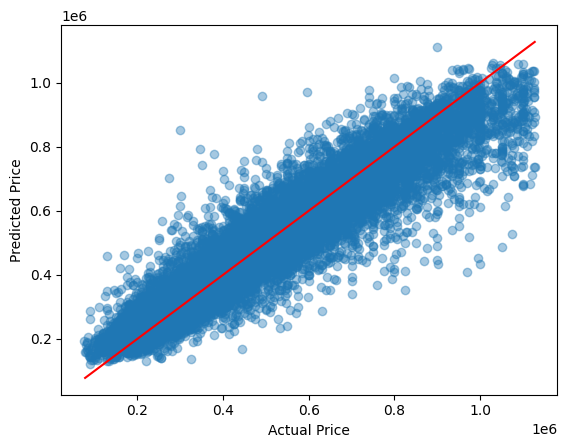

In [18]:
import matplotlib.pyplot as plt

plt.scatter(y_true, y_pred, alpha=0.4)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()